# Bag-of-Words
* CountVectorizer + MLP
* TF-IDF + MLP

In [16]:
import torch
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader, random_split

In [17]:
metadata = pd.read_csv('../datasets/Flipkart/flipkart_com-ecommerce_sample_1050.csv')
count_vectorizer = CountVectorizer()
x_countvec = torch.tensor(count_vectorizer.fit_transform(metadata['description'].values).todense(), dtype=torch.float32)

tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
x_tfidfvec = torch.tensor(tfidf_vectorizer.fit_transform(metadata['description'].values).todense(), dtype=torch.float32)

print(x_countvec.shape)
print(x_tfidfvec.shape)

# Affichage compact du vocabulaire (on evite de dumper le dictionnaire complet,
# qui peut corrompre la sauvegarde du notebook a cause de la taille de l'output)
print(f"CountVectorizer : {len(count_vectorizer.vocabulary_)} tokens")
print(f"TF-IDF          : {len(tfidf_vectorizer.vocabulary_)} tokens")

torch.Size([1050, 6053])
torch.Size([1050, 500])
CountVectorizer : 6053 tokens
TF-IDF          : 500 tokens


In [18]:
le = LabelEncoder()
y = metadata['product_category_tree'].apply(lambda x: x.split(' >> ')[0][2:])
y = le.fit_transform(y)

y = torch.tensor(y, dtype=torch.long)

In [19]:
m = x_countvec.shape[0]

x_countvec /= x_countvec.amax(axis=1, keepdim=True)
x_tfidfvec /= x_tfidfvec.amax(axis=1, keepdim=True)

x_countvec = torch.hstack([x_countvec, torch.ones((m, 1))])
x_tfidfvec = torch.hstack([x_tfidfvec, torch.ones((m, 1))])

num_classes = y.unique().shape[0]
y = torch.nn.functional.one_hot(y, num_classes=num_classes).float()

In [20]:
class FlipkartDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [21]:
# --- Utilitaire : courbe de perte train/val en direct ---
# Aucune installation nécessaire : matplotlib + IPython sont déjà dans le kernel.
import matplotlib.pyplot as plt
from IPython.display import clear_output


def live_plot_losses(history, title="Entraînement", xlabel="Epoch"):
    """Trace (et met à jour en direct) les courbes de perte train / val.

    history : dict de listes, p.ex. {"train_loss": [...], "val_loss": [...]}.
              Les clés "train_acc" / "val_acc" sont optionnelles et ajoutent
              un second panneau "accuracy".
    À appeler à la fin de chaque epoch : le graphe se redessine sur place,
    et la courbe finale reste affichée une fois l'entraînement terminé.
    """
    clear_output(wait=True)  # efface le graphe précédent -> effet "temps réel"
    has_acc = "train_acc" in history
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, ax = plt.subplots(1, 2 if has_acc else 1,
                           figsize=(12 if has_acc else 7, 4.5), squeeze=False)
    ax = ax[0]

    ax[0].plot(epochs, history["train_loss"], marker=".", label="Train")
    if history.get("val_loss"):
        ax[0].plot(epochs, history["val_loss"], marker=".", label="Val")
    ax[0].set(xlabel=xlabel, ylabel="Loss", title=f"{title} — Loss")
    ax[0].legend(); ax[0].grid(True, alpha=0.3)

    if has_acc:
        ax[1].plot(epochs, history["train_acc"], marker=".", label="Train")
        if history.get("val_acc"):
            ax[1].plot(epochs, history["val_acc"], marker=".", label="Val")
        ax[1].set(xlabel=xlabel, ylabel="Accuracy (%)", title=f"{title} — Accuracy")
        ax[1].legend(); ax[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader


class MLP(nn.Module):
    """Perceptron multicouche simple : Linear -> ReLU -> Linear."""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, t):
        return self.network(t)


def train_mlp(X, y, hidden_dim=64, batch_size=32, n_epochs=200, eta=1e-1, verbose=True, title="MLP"):
    """Entraine un MLP de maniere agnostique a la representation des features."""
    num_feats = X.shape[1]
    num_classes = y.shape[1]

    # --- Split train / validation (80 / 20) ---
    m = X.shape[0]
    perm = torch.randperm(m)
    n_val = int(0.2 * m)
    val_idx, train_idx = perm[:n_val], perm[n_val:]
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    dataset = FlipkartDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = MLP(num_feats, hidden_dim, num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=eta)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(n_epochs):
        model.train()
        total_train_loss = 0.0
        n_seen = 0
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            targets = torch.argmax(y_batch, dim=-1)
            loss = criterion(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * X_batch.size(0)
            n_seen += X_batch.size(0)

        # --- Metriques train / val + courbe en direct (remplace le print) ---
        model.eval()
        with torch.no_grad():
            train_logits = model(X_train)
            val_logits = model(X_val)
            train_targets = torch.argmax(y_train, dim=-1)
            val_targets = torch.argmax(y_val, dim=-1)
            history["train_loss"].append(total_train_loss / n_seen)
            history["val_loss"].append(criterion(val_logits, val_targets).item())
            history["train_acc"].append((torch.argmax(train_logits, dim=-1) == train_targets).float().mean().item() * 100)
            history["val_acc"].append((torch.argmax(val_logits, dim=-1) == val_targets).float().mean().item() * 100)
        if verbose:
            live_plot_losses(history, title=title)

    return model

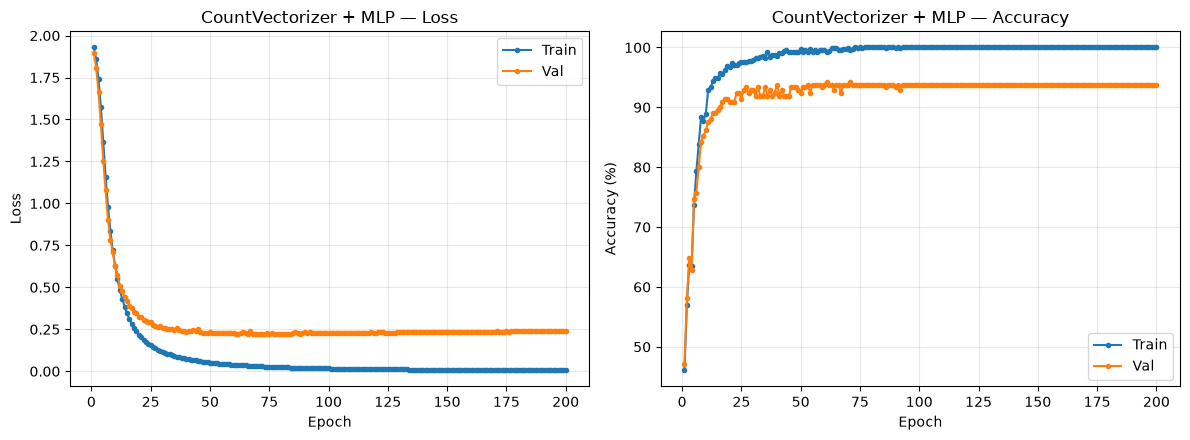

In [23]:
# CountVectorizer + MLP
model_countvec = train_mlp(x_countvec, y, title="CountVectorizer + MLP")

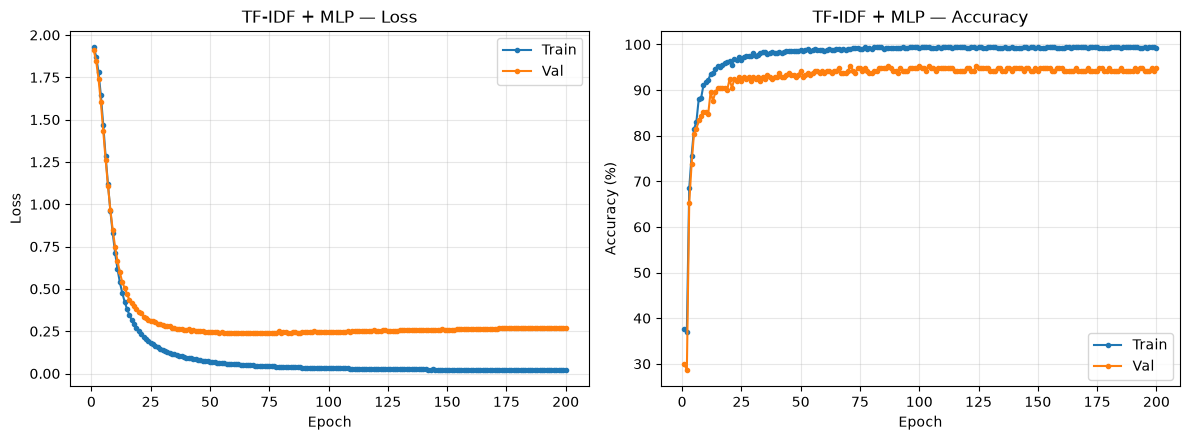

In [24]:
# TF-IDF + MLP
model_tfidf = train_mlp(x_tfidfvec, y, title="TF-IDF + MLP")

# BERT + MLP sur Flipkart
Voir https://sbert.net/ 

Pour la liste des modèles préentrainés : https://sbert.net/docs/sentence_transformer/pretrained_models.html 

In [25]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")
embeddings = model.encode(metadata['description'].values.tolist())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
embeddings.shape

(1050, 768)

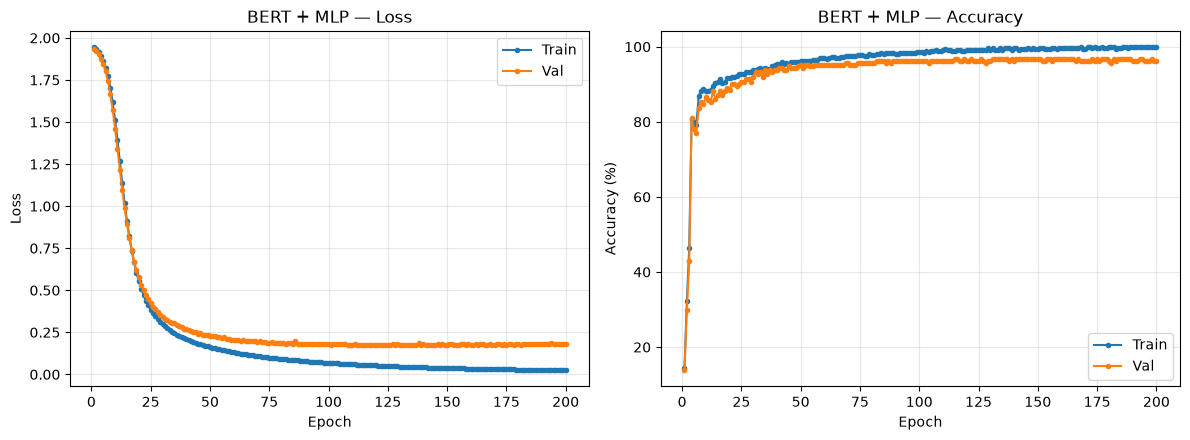

In [27]:
# BERT embeddings + MLP (meme fonction, representation differente)
model_bert = train_mlp(torch.tensor(embeddings, dtype=torch.float), y, title="BERT + MLP")

# Full Transformers sur Flipkart

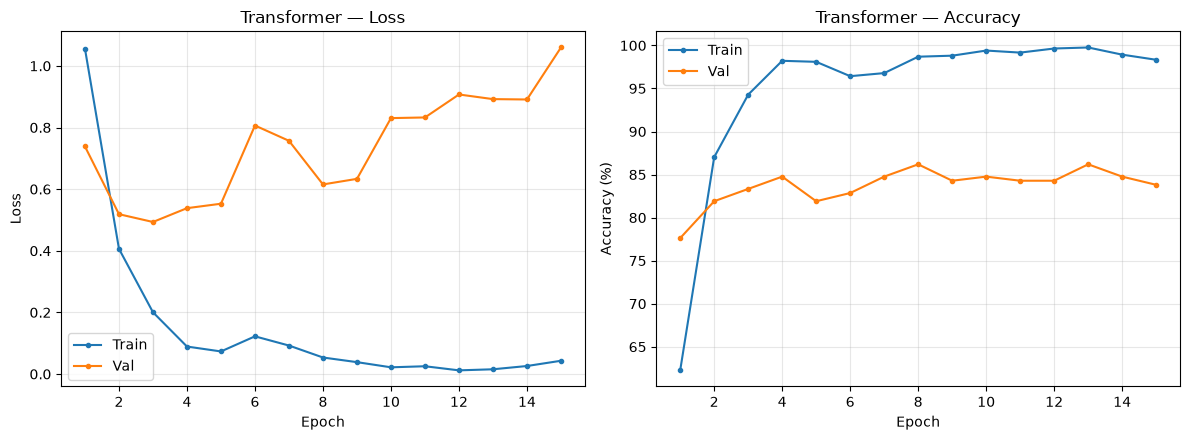

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re

# ===========================
# Parameters
# ===========================
MAX_SEQ_LEN = 16
EMBED_DIM = 128
NUM_HEADS = 2
FF_DIM = 32
NUM_LAYERS = 2
DROPOUT = 0.2
BATCH_SIZE = 8
NUM_CLASSES = 7
LR = 1e-3
EPOCHS = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

texts = metadata['description'].values.tolist()

y_tensor = torch.argmax(y, dim=1)

# ===========================
# Tokenizer + vocab
# ===========================
def simple_tokenizer(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9 ]', '', text)
    return text.split()

all_tokens = [token for text in texts for token in simple_tokenizer(text)]
vocab = {token: i+1 for i, (token, _) in enumerate(Counter(all_tokens).most_common())}
vocab_size = len(vocab) + 1

def encode(text):
    tokens = simple_tokenizer(text)
    ids = [vocab.get(tok,0) for tok in tokens]
    if len(ids) < MAX_SEQ_LEN:
        ids += [0]*(MAX_SEQ_LEN - len(ids))
    else:
        ids = ids[:MAX_SEQ_LEN]
    return ids

X_tensor = torch.tensor([encode(t) for t in texts], dtype=torch.long)

# ===========================
# Dataset & DataLoader
# ===========================
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = TextDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# ===========================
# Positional Encoding
# ===========================
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=MAX_SEQ_LEN):
        super().__init__()
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-torch.log(torch.tensor(10000.0)) / embed_dim))
        pe[:,0::2] = torch.sin(position * div_term)
        pe[:,1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(1))  # (max_len, 1, embed_dim)

    def forward(self, x):
        # x: (seq_len, batch, embed_dim)
        x = x + self.pe[:x.size(0), :]
        return x

# ===========================
# Transformer Encoder Model using nn.TransformerEncoder
# ===========================
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, num_classes, max_len=MAX_SEQ_LEN, dropout=DROPOUT):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pos_embed = PositionalEncoding(embed_dim, max_len)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embed(x)                  # (batch, seq_len, embed_dim)
        x = x.transpose(0,1)               # (seq_len, batch, embed_dim)
        x = self.pos_embed(x)              # add positional encoding
        x = self.transformer_encoder(x)    # (seq_len, batch, embed_dim)
        x = x.mean(dim=0)                  # global average pooling over sequence
        out = self.classifier(x)
        return out

# ===========================
# Instantiate model
# ===========================
model = TransformerClassifier(vocab_size=vocab_size,
                              embed_dim=EMBED_DIM,
                              num_heads=NUM_HEADS,
                              ff_dim=FF_DIM,
                              num_layers=NUM_LAYERS,
                              num_classes=NUM_CLASSES).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

from sklearn.model_selection import train_test_split

# ===========================
# Split train/validation
# ===========================
X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# ===========================
# Training loop with validation accuracy
# ===========================
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
for epoch in range(EPOCHS):
    # --- training ---
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    
    train_loss = total_loss / len(train_loader)
    train_acc = correct / total * 100

    # --- validation ---
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss_total += loss.item()
            
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
    
    val_loss = val_loss_total / len(val_loader)
    val_acc = val_correct / val_total * 100

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    live_plot_losses(history, title="Transformer")


# LSTM sur Flipkart

Avant les Transformers, les **reseaux recurrents** (RNN, LSTM, GRU) etaient l'outil de
reference pour les sequences. Un LSTM lit les tokens un a un en maintenant un **etat
cache** ; on utilise le dernier etat cache comme resume de la sequence pour classifier.

On reprend ici **exactement la meme tache et la meme tokenisation** que pour le Transformer
(categorisation produit Flipkart) afin de **comparer** une approche recurrente a
l'attention.

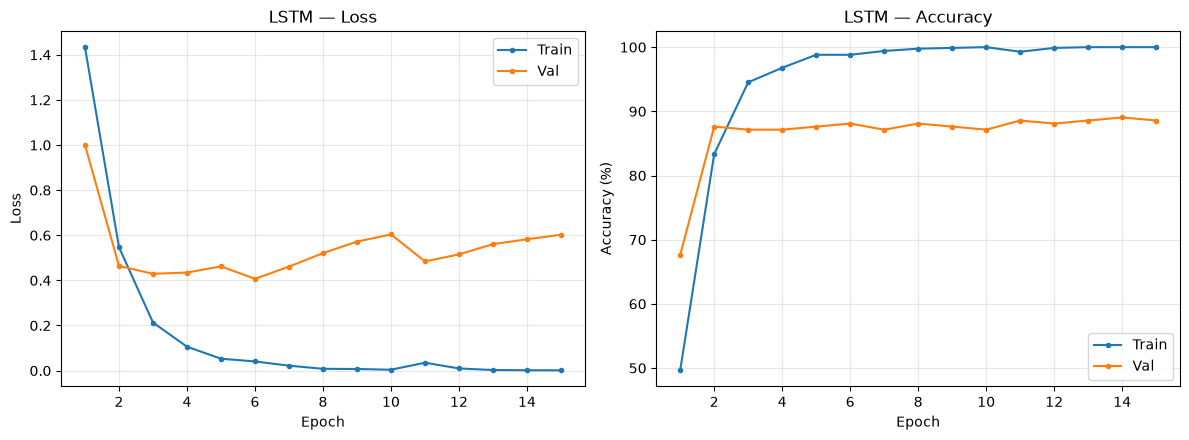

In [29]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

# On reutilise X_tensor, y_tensor, vocab_size, TextDataset, EMBED_DIM, NUM_CLASSES,
# BATCH_SIZE, EPOCHS, LR, DEVICE... definis dans la cellule Transformer (meme
# tokenisation). On reconstruit simplement les dataloaders.
X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)
train_loader_lstm = DataLoader(TextDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader_lstm   = DataLoader(TextDataset(X_val, y_val), batch_size=BATCH_SIZE)


class LSTMClassifier(nn.Module):
    """Embedding -> LSTM -> dernier etat cache -> couche lineaire."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embed(x)                # (batch, seq_len, embed_dim)
        out, (h, c) = self.lstm(emb)       # h: (num_layers, batch, hidden_dim)
        resume = h[-1]                     # dernier etat cache : (batch, hidden_dim)
        return self.classifier(resume)


lstm_model = LSTMClassifier(vocab_size, EMBED_DIM, hidden_dim=128, num_classes=NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
for epoch in range(EPOCHS):
    lstm_model.train()
    total_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader_lstm:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)
    train_loss = total_loss / len(train_loader_lstm)
    train_acc = correct / total * 100

    lstm_model.eval()
    val_correct = 0
    val_total = 0
    val_loss_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader_lstm:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = lstm_model(X_batch)
            val_loss_total += criterion(outputs, y_batch).item()
            val_correct += (outputs.argmax(1) == y_batch).sum().item()
            val_total += y_batch.size(0)
    val_loss = val_loss_total / len(val_loader_lstm)
    val_acc = val_correct / val_total * 100

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    live_plot_losses(history, title="LSTM")


# CNN vs ViT

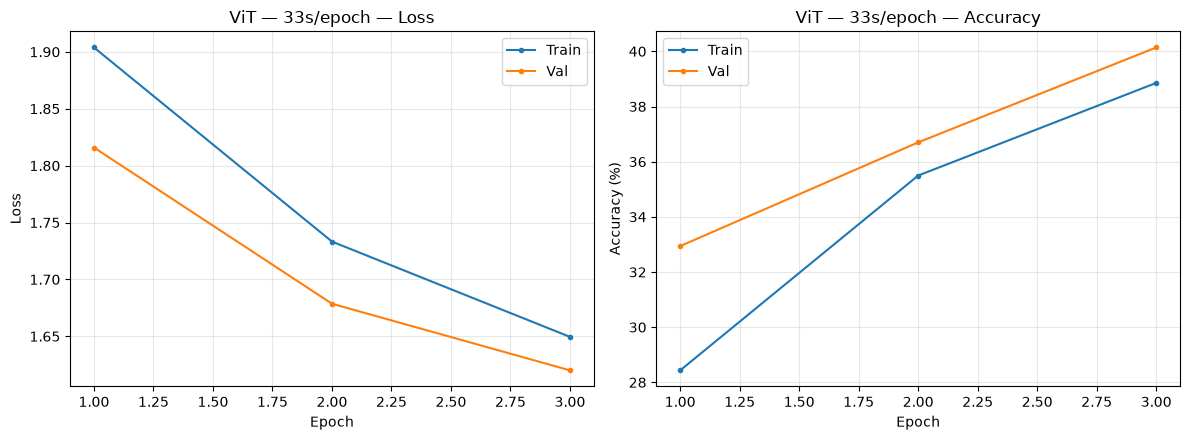

Test Accuracy: 0.4307

LeNet5_GAP Accuracy: 0.3271
ViT Accuracy: 0.4307


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import time

# ===========================
# Hyperparameters
# ===========================
batch_size = 128
num_classes = 10
num_epochs = 3
learning_rate = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===========================
# Dataset
# ===========================
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Split train / validation (80 / 20) pour suivre la courbe de validation
n_val = int(0.2 * len(train_dataset))
train_subset, val_subset = random_split(train_dataset, [len(train_dataset) - n_val, n_val])
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# ===========================
# LeNet5_GAP definition
# ===========================
class LeNet5_GAP(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5_GAP, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)  # 3 channels for CIFAR10
        self.pool1 = nn.AvgPool2d(2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(2)
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(16, num_classes)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# ===========================
# ViT definition (8x8 patches)
# ===========================
import torch
import torch.nn as nn
import torch.nn.functional as F

# ===========================
# Transformer Encoder Block
# ===========================
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (seq_len, batch, embed_dim)
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + self.dropout(attn_out)
        x_norm = self.norm2(x)
        x = x + self.mlp(x_norm)
        return x

# ===========================
# ViT Model
# ===========================
class ViT(nn.Module):
    def __init__(self, image_size=32, patch_size=8, in_channels=3, num_classes=10,
                 embed_dim=128, depth=6, num_heads=4, mlp_dim=256, dropout=0.1):
        super().__init__()
        assert image_size % patch_size == 0, "Image size must be divisible by patch size"
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_size = patch_size
        self.embed_dim = embed_dim

        # Patch embedding
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        # Transformer encoder
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim, dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # Classifier head
        self.head = nn.Linear(embed_dim, num_classes)

        # Initialize weights
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        # x: (B, C, H, W)
        B = x.shape[0]
        x = self.patch_embed(x)  # (B, embed_dim, H/patch, W/patch)
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)

        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, embed_dim)
        x = torch.cat((cls_tokens, x), dim=1)          # (B, num_patches+1, embed_dim)
        x = x + self.pos_embed
        x = self.dropout(x)

        # Transformer blocks (need seq_len, batch, embed_dim for nn.MultiheadAttention)
        x = x.transpose(0, 1)  # (seq_len, batch, embed_dim)
        for block in self.blocks:
            x = block(x)
        x = x.transpose(0, 1)  # (B, seq_len, embed_dim)

        x = self.norm(x[:, 0])  # Take CLS token
        x = self.head(x)
        return x

vit_model = ViT(image_size=32, patch_size=8, in_channels=3, num_classes=10)


# ===========================
# Training and evaluation functions
# ===========================
def train_model(model, criterion, optimizer, num_epochs, val_loader=None, title="Entraînement"):
    model = model.to(device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(100 * correct / total)

        # --- Validation ---
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * images.size(0)
                    _, predicted = outputs.max(1)
                    val_total += labels.size(0)
                    val_correct += predicted.eq(labels).sum().item()
            history["val_loss"].append(val_loss / val_total)
            history["val_acc"].append(100 * val_correct / val_total)

        # Courbe train/val en direct (remplace le print par epoch)
        live_plot_losses(history, title=f"{title} — {time.time()-start_time:.0f}s/epoch")

def evaluate_model(model):
    model.eval()
    model = model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    acc = correct / total
    print(f"Test Accuracy: {acc:.4f}")
    return acc

# ===========================
# Train and evaluate LeNet5_GAP
# ===========================
print("=== Training LeNet5_GAP ===")
lenet_model = LeNet5_GAP(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lenet_model.parameters(), lr=learning_rate)

train_model(lenet_model, criterion, optimizer, num_epochs, val_loader, title="LeNet5-GAP")
acc_lenet = evaluate_model(lenet_model)

# ===========================
# Train and evaluate ViT
# ===========================
print("\n=== Training ViT (8x8 patches) ===")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit_model.parameters(), lr=learning_rate)

train_model(vit_model, criterion, optimizer, num_epochs, val_loader, title="ViT")
acc_vit = evaluate_model(vit_model)

print(f"\nLeNet5_GAP Accuracy: {acc_lenet:.4f}")
print(f"ViT Accuracy: {acc_vit:.4f}")
